
SIMON'S ALGORITHM - 3-BIT SECRET
Secret string: 110

QUANTUM CIRCUIT
          ┌───┐ ░                      ░ ┌───┐ ░ ┌─┐      
 input_0: ┤ H ├─░───■──────────────────░─┤ H ├─░─┤M├──────
          ├───┤ ░   │                  ░ ├───┤ ░ └╥┘┌─┐   
 input_1: ┤ H ├─░───┼────■─────────────░─┤ H ├─░──╫─┤M├───
          ├───┤ ░   │    │             ░ ├───┤ ░  ║ └╥┘┌─┐
 input_2: ┤ H ├─░───┼────┼────■────■───░─┤ H ├─░──╫──╫─┤M├
          └───┘ ░ ┌─┴─┐  │  ┌─┴─┐  │   ░ └───┘ ░  ║  ║ └╥┘
output_0: ──────░─┤ X ├──┼──┤ X ├──┼───░───────░──╫──╫──╫─
                ░ └───┘┌─┴─┐└───┘┌─┴─┐ ░       ░  ║  ║  ║ 
output_1: ──────░──────┤ X ├─────┤ X ├─░───────░──╫──╫──╫─
                ░      └───┘     └───┘ ░       ░  ║  ║  ║ 
output_2: ──────░──────────────────────░───────░──╫──╫──╫─
                ░                      ░       ░  ║  ║  ║ 
  meas: 3/════════════════════════════════════════╩══╩══╩═
                                                  0  1  2 

MEASUREMENT RESULTS
Shots : 2000
Counts: {'1

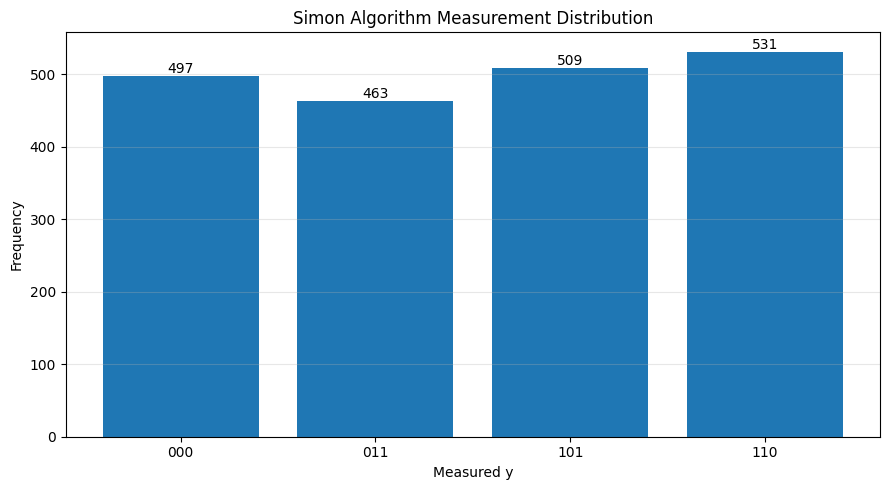

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler

SECRET = "110"
N = len(SECRET)
SHOTS = 2000

q_in = QuantumRegister(N, "input")
q_out = QuantumRegister(N, "output")
meas = ClassicalRegister(N, "meas")

qc = QuantumCircuit(q_in, q_out, meas)

for i in range(N):
    qc.h(q_in[i])

qc.barrier()

# Simon oracle for secret string 110
# f(x) = (x0 XOR x2, x1 XOR x2, 0)

qc.cx(q_in[0], q_out[0])
qc.cx(q_in[2], q_out[0])

qc.cx(q_in[1], q_out[1])
qc.cx(q_in[2], q_out[1])

qc.barrier()

for i in range(N):
    qc.h(q_in[i])

qc.barrier()

for i in range(N):
    qc.measure(q_in[i], meas[i])

print("\nSIMON'S ALGORITHM - 3-BIT SECRET")
print("=" * 60)
print("Secret string:", SECRET)

print("\nQUANTUM CIRCUIT")
print("=" * 60)
print(qc.draw())

sampler = StatevectorSampler()

result = sampler.run(
    [qc],
    shots=SHOTS
).result()

counts = result[0].data.meas.get_counts()

print("\nMEASUREMENT RESULTS")
print("=" * 60)
print("Shots :", SHOTS)
print("Counts:", counts)

valid_equations = []

for y in counts:
    y = y[::-1]

    if y == "000":
        continue

    dot_product = sum(
        int(y[i]) * int(SECRET[i])
        for i in range(N)
    ) % 2

    if dot_product == 0:
        if y not in valid_equations:
            valid_equations.append(y)

print("\nSIMON EQUATIONS")
print("=" * 60)

for equation in valid_equations:
    print(equation, " . ", SECRET, " = 0 (mod 2)")

print("\nINDEPENDENT EQUATIONS")
print("=" * 60)

independent = []

for equation in valid_equations:
    if len(independent) == 0:
        independent.append(equation)
    else:
        rank_before = np.linalg.matrix_rank(
            np.array(
                [[int(bit) for bit in row] for row in independent],
                dtype=float
            )
        )

        candidate = independent + [equation]

        rank_after = np.linalg.matrix_rank(
            np.array(
                [[int(bit) for bit in row] for row in candidate],
                dtype=float
            )
        )

        if rank_after > rank_before:
            independent.append(equation)

    if len(independent) >= N - 1:
        break

for equation in independent:
    print(equation)

print("\nSECRET VERIFICATION")
print("=" * 60)

all_valid = True

for equation in independent:
    value = sum(
        int(equation[i]) * int(SECRET[i])
        for i in range(N)
    ) % 2

    if value != 0:
        all_valid = False

if all_valid and len(independent) >= N - 1:
    print("Independent equations satisfy y . s = 0.")
    print("Recovered secret string:", SECRET)
    print("Oracle correctness verified.")
else:
    print("More independent equations are required.")

# Measurement distribution graph

labels = sorted(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, values)

plt.xlabel("Measured y")
plt.ylabel("Frequency")
plt.title("Simon Algorithm Measurement Distribution")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
%pip install -U qiskit numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: matplotlib 3.7.50/2 [numpy]
    Uninstalling matplotlib-3.7.5:━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled matplotlib-3.7.5━━━━━━━━━━━━━━━━━━━ 1/2 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib]2 [matplotlib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of 